In [1]:
import pandas as pd
import numpy as np

import pandas as pd

url = "https://idh-be.iowa.gov/api/v1/datasets/1051/rows.csv"

df = pd.read_csv(url)

alc type and temperature

In [2]:
df = pd.read_parquet("liquor.parquet")

pd.set_option("display.max_columns", None)

df.head(10)

,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,category_name,vendor_number,vendor_name,item_no,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_bottles,sales_dollars,sales_liters,sales_gallons
0,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158,19127,MARSHALL,1022200,100% AGAVE TEQUILA,035,BACARDI USA INC,88296,PATRON SILVER,12,750,24.99,37.49,60,2249.40,45.0,11.887740
1,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158,19127,MARSHALL,1082200,IMPORTED SCHNAPPS,260,DIAGEO AMERICAS,69947,RUMPLE MINZE PEPPERMINT SCHNAPPS LIQUEUR,12,1000,16.99,25.49,36,917.64,36.0,9.510192
2,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1022200,100% AGAVE TEQUILA,260,DIAGEO AMERICAS,87484,DON JULIO BLANCO,12,375,14.00,22.00,3,67.00,1.0,0.000000
3,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1022200,100% AGAVE TEQUILA,035,BACARDI USA INC,88296,PATRON SILVER,12,750,24.00,37.00,12,449.00,9.0,2.000000
4,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1081300,AMERICAN CORDIALS & LIQUEUR,421,SAZERAC COMPANY INC,84393,99 WATERMELON PET MINI,1,50,54.00,81.00,1,81.00,0.0,0.000000
5,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1081400,AMERICAN SCHNAPPS,421,SAZERAC COMPANY INC,101180,99 FRUITS MINI,1,50,54.00,81.00,1,81.00,0.0,0.000000
6,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1031100,AMERICAN VODKAS,777,"BLUE OX SPIRITS, INC.",36875,BLUE OX VODKA,6,1750,7.00,11.00,6,68.00,10.0,2.000000
7,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1031100,AMERICAN VODKAS,434,LUXCO INC,36308,HAWKEYE VODKA,6,1750,7.00,11.00,6,67.00,10.0,2.000000
8,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1031100,AMERICAN VODKAS,434,LUXCO INC,36306,HAWKEYE VODKA,12,750,3.00,5.00,12,63.00,9.0,2.000000
9,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1031100,AMERICAN VODKAS,205,E & J GALLO WINERY,36968,NEW AMSTERDAM 80PRF,24,375,4.00,6.00,4,24.00,1.0,0.000000


if liters = 1, then gallons = 0. probs too small to make it 1 gal.

if small ml then no liters and gallons. (obs 5 and 6)

probs choose ml and liters

decide how to aggregate

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952161 entries, 0 to 1952160
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   invoice_id           object 
 1   ordered_on           object 
 2   store_no             object 
 3   store_name           object 
 4   store_address        object 
 5   store_city           object 
 6   store_zip_code       object 
 7   county_fips_code     object 
 8   county_name          object 
 9   category_code        object 
 10  category_name        object 
 11  vendor_number        object 
 12  vendor_name          object 
 13  item_no              object 
 14  im_desc              object 
 15  pack                 object 
 16  bottle_volume_ml     int64  
 17  state_bottle_cost    float64
 18  state_bottle_retail  float64
 19  sales_bottles        object 
 20  sales_dollars        float64
 21  sales_liters         float64
 22  sales_gallons        float64
dtypes: float64(5), int64(1), object(

In [5]:
df.dtypes

invoice_id              object
ordered_on              object
store_no                object
store_name              object
store_address           object
store_city              object
store_zip_code          object
county_fips_code        object
county_name             object
category_code           object
category_name           object
vendor_number           object
vendor_name             object
item_no                 object
im_desc                 object
pack                    object
bottle_volume_ml         int64
state_bottle_cost      float64
state_bottle_retail    float64
sales_bottles           object
sales_dollars          float64
sales_liters           float64
sales_gallons          float64
dtype: object

In [6]:
df["sales_bottles"] = pd.to_numeric(df["sales_bottles"])
df["ordered_on"] = pd.to_datetime(df["ordered_on"])

In [6]:
df.isna().sum()

invoice_id                0
ordered_on                0
store_no                  0
store_name                0
store_address             0
store_city                0
store_zip_code            0
county_fips_code       4129
county_name               0
category_code             0
category_name             0
vendor_number             0
vendor_name               0
item_no                   0
im_desc                   0
pack                      0
bottle_volume_ml          0
state_bottle_cost         0
state_bottle_retail       0
sales_bottles             0
sales_dollars             0
sales_liters              0
sales_gallons             0
dtype: int64

In [ ]:
dfclean = df.drop(columns = ["invoice_id", "store_address", "county_fips_code", "sales_gallons"])
dfclean.shape

(1952161, 19)

In [12]:
df["sales_liters"].value_counts().sort_index()

sales_liters
-120.0      2
-84.0       4
-72.0       1
-63.0       1
-60.0       1
           ..
 4200.0     1
 5280.0     2
 9900.0     2
 10560.0    1
 13200.0    1
Name: count, Length: 632, dtype: int64

In [10]:
df["bottle_volume_ml"].value_counts().sort_index()

bottle_volume_ml
20         176
25        1498
50      313153
100      56087
200      57111
375     225526
700       9064
750     790769
800          2
850         24
1000    167400
1100         6
1125        39
1750    329791
3000      1362
3750        18
4500       135
Name: count, dtype: int64

In [18]:
df["sales_dollars"].value_counts().sort_index()

sales_dollars
-3240.00      1
-2835.00      1
-2519.04      1
-1800.00      1
-1328.40      1
             ..
 81858.00     1
 104332.80    2
 195624.00    2
 208665.60    1
 260832.00    1
Name: count, Length: 8940, dtype: int64

negative values xd

In [32]:
dfclean.groupby(dfclean["ordered_on"].dt.to_period("M"))["sales_dollars"].count()

ordered_on
2026-01    182995
2026-02    174168
2026-03    201947
2026-04    199762
2026-05    206075
2026-06    219923
2026-07    364179
2026-08    403112
Freq: M, Name: sales_dollars, dtype: int64

# Visualizations

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

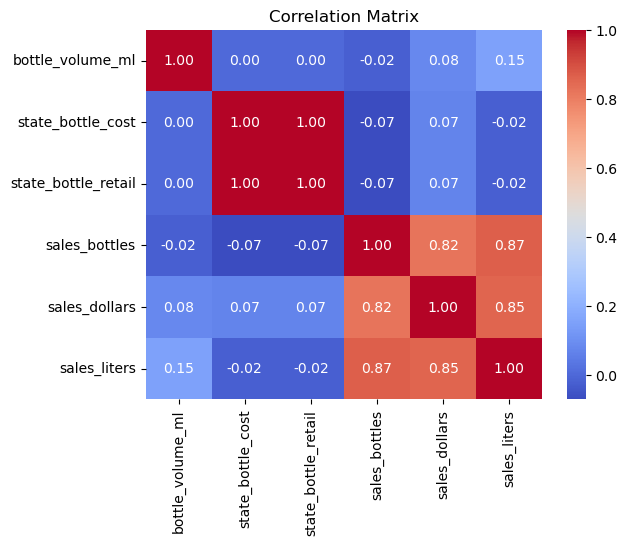

In [27]:
corr = dfclean.corr(numeric_only = True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Text(0.5, 1.0, 'Distribution of Sale Dollars')

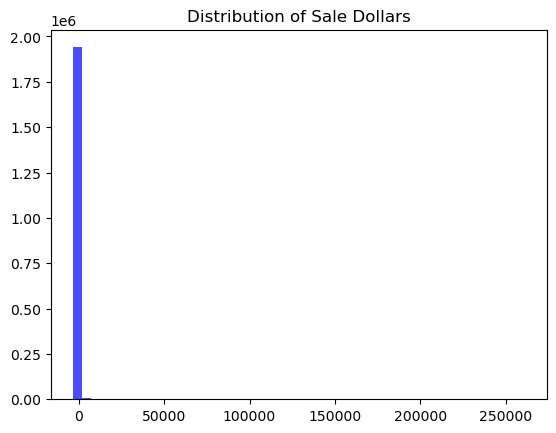

In [ ]:
plt.hist(dfclean['sales_dollars'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Sale Dollars')

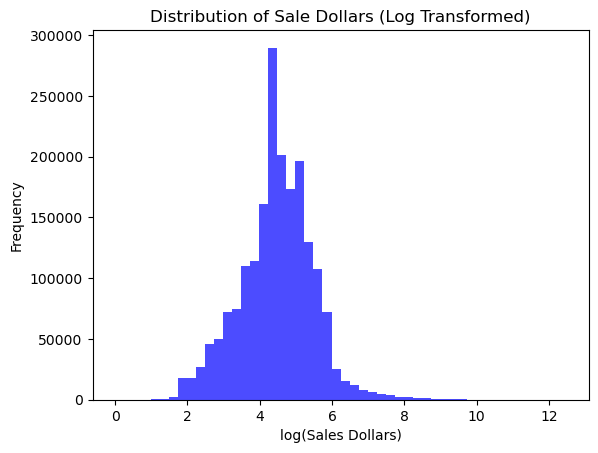

In [28]:
temp_df = dfclean[dfclean["sales_dollars"] > 0]

plt.hist(np.log(temp_df["sales_dollars"]), bins=50, color="blue", alpha=0.7)
plt.title("Distribution of Sale Dollars (Log Transformed)")
plt.xlabel("log(Sales Dollars)")
plt.ylabel("Frequency")

plt.show()

prob log scale the sales_dollars when modeling